In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


import jax
import jax.numpy as jnp


import metanet
import persistentExitationSimulation as pes

In [2]:
traj_true, params, boundaries, initial_state  = pes.simulate_example()

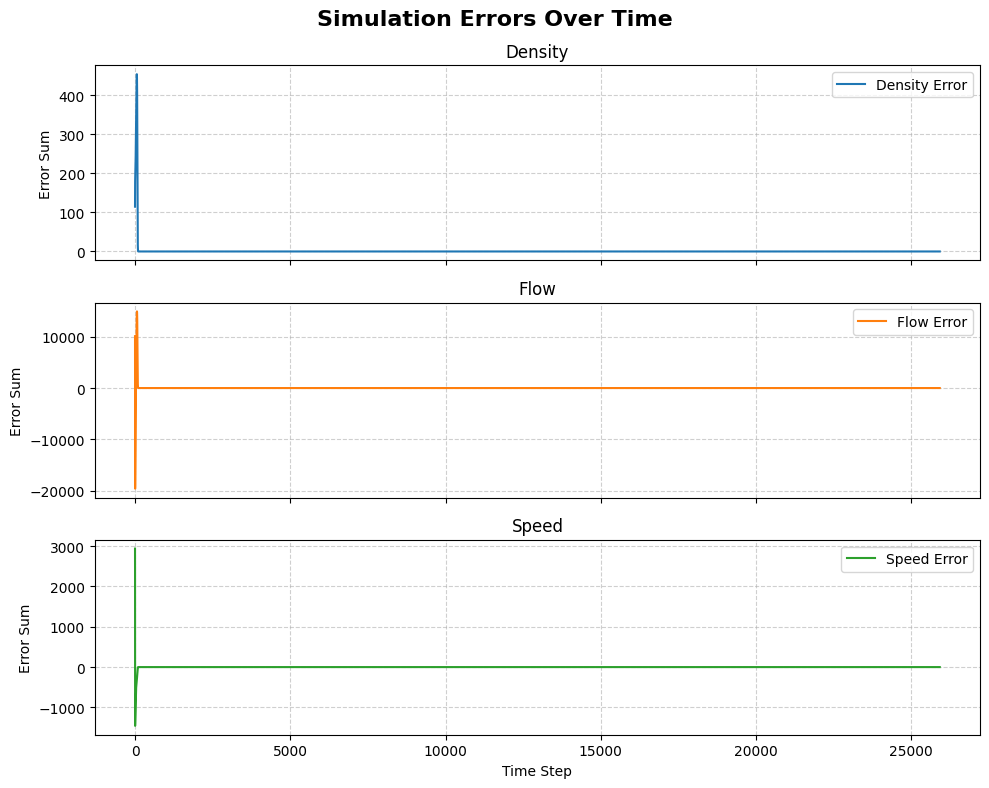

In [ ]:
def disturb_array(key, measurment, dl=1):
    return jnp.exp(jax.random.normal(key, measurment.shape)*dl)*measurment

keys = jax.random.split(jax.random.PRNGKey(1129), 3)
disturbed_ini_state = metanet.NetworkState(
    density = disturb_array(keys[0],initial_state.density),
    flow = disturb_array(keys[1],initial_state.flow),
    speed = disturb_array(keys[2],initial_state.speed)
)

dist_traj = metanet.rollout_simulation(disturbed_ini_state, boundaries, params)

error_density = jnp.sum(dist_traj.density - traj_true.density, axis = 1) 
error_flow = jnp.sum(dist_traj.flow - traj_true.flow, axis=1)
error_speed = jnp.sum(dist_traj.speed - traj_true.speed,axis=1)

# sharex=True ensures they all share the bottom X-axis labels.
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Simulation Errors Over Time', fontsize=16, fontweight='bold')

time_steps = range(error_density.size)

# 1. Density Error Plot
axes[0].plot(time_steps, error_density, label='Density Error', color="tab:blue", linewidth=1.5)
axes[0].set_ylabel('Error Sum')
axes[0].set_title('Density')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right')

# 2. Flow Error Plot
axes[1].plot(time_steps, error_flow, label='Flow Error', color="tab:orange", linewidth=1.5)
axes[1].set_ylabel('Error Sum')
axes[1].set_title('Flow')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

# 3. Speed Error Plot
axes[2].plot(time_steps, error_speed, label='Speed Error', color="tab:green", linewidth=1.5)
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Error Sum')
axes[2].set_title('Speed')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right')

# Adjust layout to prevent clipping and display the plot
plt.tight_layout()
plt.show()
